<a href="https://colab.research.google.com/github/greeshmapj/AI-course-notes/blob/main/Sec29_Intro_to_Convolution_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Convolutional Neural Networks (CNN
## 1. What is a CNN?

A **Convolutional Neural Network (CNN)** is a type of **Deep Learning model** designed to work with images.

It automatically learns patterns from images, such as:

- edges
- shapes
- textures
- objects

CNNs are widely used in:

- Image classification
- Face recognition
- Object detection
- Medical image analysis

Example dataset: **MNIST (handwritten digit recognition)**.

---

# 2. Why CNN Instead of Normal Neural Networks?

In normal neural networks:

- Images must be **flattened**
- Spatial relationships are **lost**
- Too many **parameters**

CNN solves this by:

- preserving **spatial structure**
- learning **local features**

Example:


Image
28 × 28 pixels


CNN processes **small regions of the image** instead of the whole image.

---

# 3. Structure of a CNN

A CNN usually has three main parts:


Input Layer

↓

Feature Extraction


Convolution Layer


Pooling Layer

↓

Classification


Fully Connected Layer

↓

Output Layer


---

# 4. Input Layer

The input layer receives the **image as a matrix of pixel values**.

Example (**MNIST image**):


28 × 28 × 1


| Dimension | Meaning |
|----------|---------|
| 28 | Height |
| 28 | Width |
| 1 | Channel (Grayscale) |

For color images:


Height × Width × 3


Channels represent **RGB**.

---

# 5. Convolution Layer

The convolution layer extracts **features from the image** using small filters.

Example filter:


1 0 -1

1 0 -1

1 0 -1


The filter **slides across the image** and produces a **feature map**.

This operation is called **Convolution**.

### Purpose

- detect edges
- detect curves
- detect patterns

---

# 6. Activation Function

After convolution, an activation function is applied.

Common activation:

**ReLU (Rectified Linear Unit)**

Formula:


f(x) = max(0, x)


### Purpose

- introduces **non-linearity**
- helps the network learn **complex patterns**

---

# 7. Pooling Layer

Pooling reduces the **size of feature maps**.

Most common pooling:

**Max Pooling**

Example:


4 2

1 5


Output:


5


This operation is called **Max Pooling**.

### Advantages

- reduces computation
- reduces overfitting
- keeps important features

---

# 8. Flatten Layer

After several convolution and pooling layers, we convert the feature maps into a **1D vector**.

Example:


7 × 7 × 64 → 3136


This step is called **Flattening**.

---

# 9. Fully Connected Layer

These layers behave like **traditional neural networks**.

They:

- combine all extracted features
- learn complex relationships
- perform classification

Example:


Dense(128)


---

# 10. Output Layer

The output layer gives **final predictions**.

For MNIST:


Dense(10)


Because there are **10 digit classes (0–9)**.

The **Softmax Function** converts outputs into probabilities.

Example:


[0.01, 0.02, 0.90, 0.03, ...]


Prediction → **digit 2**

---

# 11. Example CNN Architecture


Input: 28×28×1 image

↓

Conv2D (32 filters, 3×3)

↓

MaxPooling (2×2)

↓

Conv2D (64 filters, 3×3)

↓

MaxPooling (2×2)

↓

Flatten

↓

Dense (128 neurons)

↓

Dense (10 neurons, Softmax)

In [37]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist #image classification (digit classification  0-9)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import matplotlib.pyplot as plt

In [38]:
(X_train, y_train), (X_test, y_test) = mnist.load_data() #70k data(60k - train , 10 k test)

In [39]:
print(X_train.shape) #(no: of images, length, width) #784 pixels in each pic

(60000, 28, 28)


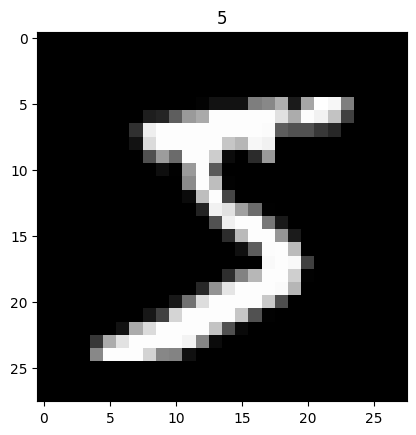

In [40]:
plt.imshow(X_train[0], cmap='gray') #0 to 59999
plt.title(y_train[0])
plt.show()

In [41]:
X_train = X_train.reshape(-1,28,28,1) #(no: of imgs, len, width, color)
X_test = X_test.reshape(-1,28,28,1)

In [42]:
X_train = X_train/255
X_test = X_test/255

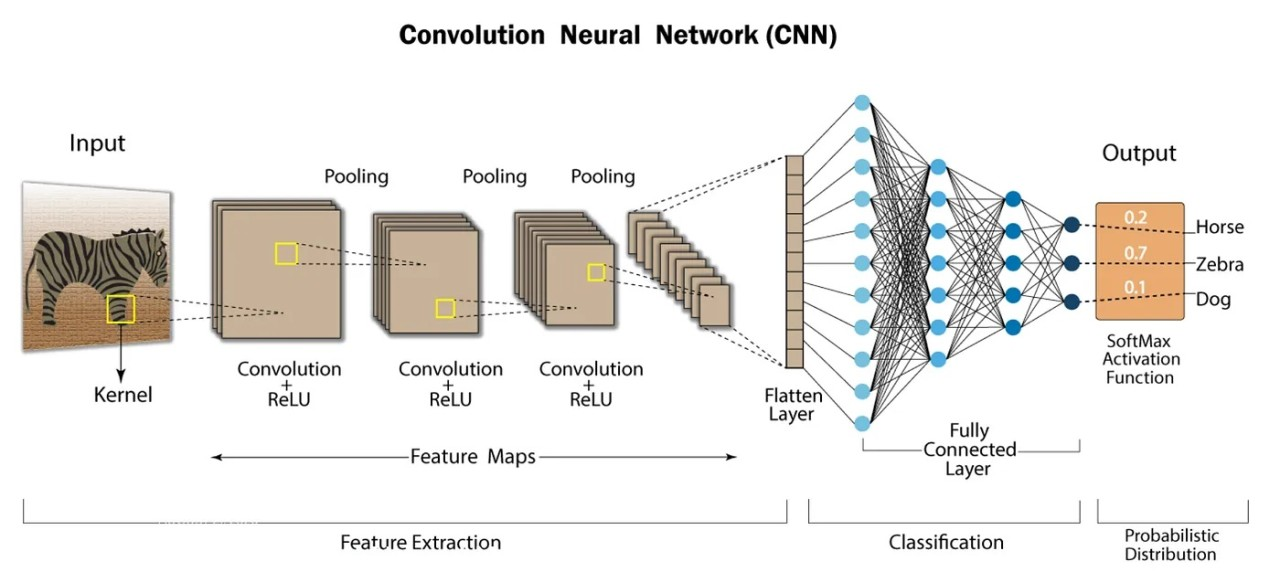

In [43]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(128,activation='relu')) #dense layer(hidden layer)
model.add(Dense(10,activation='softmax')) # class 10

# Simple CNN Example (Conv 3×3 + Pooling 2×2)

## 1. Original Image (5×5)

1  2  3  0  1  
4  5  6  1  2  
7  8  9  2  3  
1  2  3  4  5  
6  7  8  9  0  

These numbers are pixel intensities.

---

# 2. Convolution (3×3)

Example filter:

1  0  -1  
1  0  -1  
1  0  -1  

This filter slides across the image.

Example region:

1 2 3  
4 5 6  
7 8 9  

Multiply element-wise and add:

(1×1)+(2×0)+(3×-1)    
(4×1)+(5×0)+(6×-1)   
(7×1)+(8×0)+(9×-1)  

Result = -2-2-2=-6

After scanning the image, feature map becomes:

-6  -6  -2  
-6  -6  -2  
 0   0   6  

---

# 3. ReLU Activation

ReLU removes negative values.

Formula:

ReLU(x) = max(0,x)

After ReLU:

0 0 0  
0 0 0  
0 0 6  

---

# 4. Max Pooling (2×2)

Take 2×2 blocks and keep the maximum value.

Example block:

0 0  
0 0  

Max = 0

Next block:

0 0  
0 6  

Max = 6

Final pooled output:

0 6

---

# Final CNN Flow

Image  
↓  
Conv2D (3×3) → detect features  
↓  
ReLU → remove negatives  
↓  
MaxPooling (2×2) → reduce size but keep strongest features

In [44]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
history = model.fit(
    X_train,
    y_train,
    epochs=1 , #early stopping
     validation_data=(X_test,y_test)
)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.9618 - loss: 0.1269 - val_accuracy: 0.9851 - val_loss: 0.0434


In [46]:
test_loss, test_acc = model.evaluate(X_test,y_test)

print("Test Accuracy:",test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9851 - loss: 0.0434
Test Accuracy: 0.9850999712944031


In [47]:
import numpy as np

prediction = model.predict(X_test[0].reshape(1,28,28,1))

print("Predicted Digit:",np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Predicted Digit: 7


In [48]:
#unseen data from googlee

from PIL import Image
import numpy as np

img = Image.open("/content/digit_16.png").convert("L")

#1. grayscale

In [49]:
img = img.resize((28,28))
#2. pixel adjust

In [50]:
img_array = np.array(img)
img_array=img_array/255
#3. image --convert it into numbers /array (divide by 225)
#4. normalization

In [51]:
img_array = img_array.reshape(1,28,28,1)

#cnn heart( 1 photo, pixels  pix, b/w)

In [52]:
prediction = model.predict(img_array)

print("Predicted Digit:", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Predicted Digit: 7


# **project 2**

In [53]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

In [54]:
dataset, info = tfds.load('oxford_iiit_pet', with_info=True, as_supervised=True)

| Property     | Value                        |
| ------------ | ---------------------------- |
| Total Images | ~7,349                       |
| Classes      | 37 pet breeds                |
| Categories   | Dogs + Cats                  |
| Image Type   | RGB images                   |
| Tasks        | Classification, Segmentation |


In [55]:
train_data = dataset['train']
test_data = dataset['test']

In [56]:
print(info)

tfds.core.DatasetInfo(
    name='oxford_iiit_pet',
    full_name='oxford_iiit_pet/4.0.0',
    description="""
    The Oxford-IIIT pet dataset is a 37 category pet image dataset with roughly 200
    images for each class. The images have large variations in scale, pose and
    lighting. All images have an associated ground truth annotation of breed and
    species. Additionally, head bounding boxes are provided for the training split,
    allowing using this dataset for simple object detection tasks. In the test
    split, the bounding boxes are empty.
    """,
    homepage='http://www.robots.ox.ac.uk/~vgg/data/pets/',
    data_dir='/root/tensorflow_datasets/oxford_iiit_pet/4.0.0',
    file_format=tfrecord,
    download_size=773.52 MiB,
    dataset_size=773.68 MiB,
    features=FeaturesDict({
        'file_name': Text(shape=(), dtype=string),
        'head_bbox': BBoxFeature(shape=(4,), dtype=float32),
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLab

In [57]:
IMG_SIZE = 128

def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE)) #(128,128,3)
    image = image / 255.0
    return image, label

In [58]:
train_data = train_data.map(preprocess)
test_data = test_data.map(preprocess)

In [59]:
BATCH_SIZE = 32

train_data = train_data.shuffle(1000).batch(BATCH_SIZE)
test_data = test_data.batch(BATCH_SIZE)

In [60]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128,(3,3),activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dense(37,activation='softmax')

]) # try vgg??

In [61]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [62]:
history = model.fit(
    train_data,
    epochs=1,  #10
    validation_data=test_data
)

115/115 ━━━━━━━━━━━━━━━━━━━━ 161s 1s/step - accuracy: 0.0421 - loss: 3.5716 - val_accuracy: 0.0649 - val_loss: 3.4863


In [63]:
loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", accuracy)

115/115 ━━━━━━━━━━━━━━━━━━━━ 40s 346ms/step - accuracy: 0.0649 - loss: 3.4863
Test Accuracy: 0.06486780941486359


In [69]:
import numpy as np
from tensorflow.keras.preprocessing import image

img = image.load_img("/content/Funny_Dog_S.jpg", target_size=(128,128))
img = image.img_to_array(img)
img = img/255.0
img = np.expand_dims(img,axis=0) #axis=0 simply means add the new dimension at position 0 (the front).

prediction = model.predict(img)

print("Predicted class:", prediction.argmax())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
Predicted class: 7


In [70]:
pred_class = prediction.argmax()
class_names = info.features['label'].names
class_names[26]

'Ragdoll'

In [71]:
print("Predicted class index:", pred_class)
print("Predicted breed:", class_names[pred_class])

Predicted class index: 7
Predicted breed: Bombay
